In [10]:
"""
student-performance-analysis/
│
├── data/
│   └── student-mat.csv
│
├── notebooks/
│   └── student_performance_analysis.ipynb
│
├── figures/
│   ├── g3_distribution.png
│   ├── studytime_vs_g3.png
│   ├── failures_vs_g3.png
│   └── ...
│
├── report/
│   └── student_performance_analysis.pptx
│
└── README.md
"""

'\nstudent-performance-analysis/\n│\n├── data/\n│   └── student-mat.csv\n│\n├── notebooks/\n│   └── student_performance_analysis.ipynb\n│\n├── figures/\n│   ├── g3_distribution.png\n│   ├── studytime_vs_g3.png\n│   ├── failures_vs_g3.png\n│   └── ...\n│\n├── report/\n│   └── student_performance_analysis.pptx\n│\n└── README.md\n'

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

In [12]:
df = pd.read_csv(r'C:\Users\Kato\Version3.12\student-perfomance-analysis\data\student-mat.csv', sep=';')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [13]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [14]:
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [15]:
df['G3'].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

In [16]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [17]:
df[['studytime', 'G1', 'G2', 'G3']].head(5)

,studytime,G1,G2,G3
0,2,5,6,6
1,2,5,5,6
2,2,7,8,10
3,3,15,14,15
4,2,6,10,10


In [18]:
df[['studytime', 'G3']].corr()

,studytime,G3
studytime,1.00000,0.09782
G3,0.09782,1.00000


In [19]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [20]:
df.dtypes.value_counts()

str      17
int64    16
Name: count, dtype: int64

### inspecting the data

In [21]:
numerical_cols = ['age', 'absences', 'G1', 'G2', 'G3']
ordinal_cols = ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']
binary_cols = ['sex', 'address', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
nominal_cols = ['school', 'Mjob', 'Fjob', 'reason', 'guardian']

In [22]:
df[numerical_cols].describe()

,age,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,5.708861,10.908861,10.713924,10.415190
std,1.276043,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,75.000000,19.000000,19.000000,20.000000


In [23]:
df[ordinal_cols].min()

Medu          0
Fedu          0
traveltime    1
studytime     1
failures      0
famrel        1
freetime      1
goout         1
Dalc          1
Walc          1
health        1
dtype: int64

In [24]:
for col in ordinal_cols:
    print(df[col].value_counts())

Medu
4    131
2    103
3     99
1     59
0      3
Name: count, dtype: int64
Fedu
2    115
3    100
4     96
1     82
0      2
Name: count, dtype: int64
traveltime
1    257
2    107
3     23
4      8
Name: count, dtype: int64
studytime
2    198
1    105
3     65
4     27
Name: count, dtype: int64
failures
0    312
1     50
2     17
3     16
Name: count, dtype: int64
famrel
4    195
5    106
3     68
2     18
1      8
Name: count, dtype: int64
freetime
3    157
4    115
2     64
5     40
1     19
Name: count, dtype: int64
goout
3    130
2    103
4     86
5     53
1     23
Name: count, dtype: int64
Dalc
1    276
2     75
3     26
5      9
4      9
Name: count, dtype: int64
Walc
1    151
2     85
3     80
4     51
5     28
Name: count, dtype: int64
health
5    146
3     91
4     66
1     47
2     45
Name: count, dtype: int64


In [25]:
for col in (nominal_cols + binary_cols):
    print(df[col].value_counts())

school
GP    349
MS     46
Name: count, dtype: int64
Mjob
other       141
services    103
at_home      59
teacher      58
health       34
Name: count, dtype: int64
Fjob
other       217
services    111
teacher      29
at_home      20
health       18
Name: count, dtype: int64
reason
course        145
home          109
reputation    105
other          36
Name: count, dtype: int64
guardian
mother    273
father     90
other      32
Name: count, dtype: int64
sex
F    208
M    187
Name: count, dtype: int64
address
U    307
R     88
Name: count, dtype: int64
famsize
GT3    281
LE3    114
Name: count, dtype: int64
Pstatus
T    354
A     41
Name: count, dtype: int64
schoolsup
no     344
yes     51
Name: count, dtype: int64
famsup
yes    242
no     153
Name: count, dtype: int64
paid
no     214
yes    181
Name: count, dtype: int64
activities
yes    201
no     194
Name: count, dtype: int64
nursery
yes    314
no      81
Name: count, dtype: int64
higher
yes    375
no      20
Name: count, dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
def get_outliers(dataframe, column):
    stat_summary = dataframe[column].describe()
    q1 = stat_summary['25%']
    q3 = stat_summary['75%']
    iqr = q3 - q1
    lower_lim = q1 - 1.5 * iqr
    upper_lim = q3 + 1.5 * iqr
    outliers = []
    for cell in dataframe[column].values:
        if cell < lower_lim or cell > upper_lim:
            outliers.append(cell)
    return outliers

In [28]:
get_outliers(df, 'absences')

[np.int64(25),
 np.int64(54),
 np.int64(26),
 np.int64(56),
 np.int64(24),
 np.int64(28),
 np.int64(22),
 np.int64(21),
 np.int64(75),
 np.int64(22),
 np.int64(30),
 np.int64(38),
 np.int64(22),
 np.int64(40),
 np.int64(23)]

### eda begins

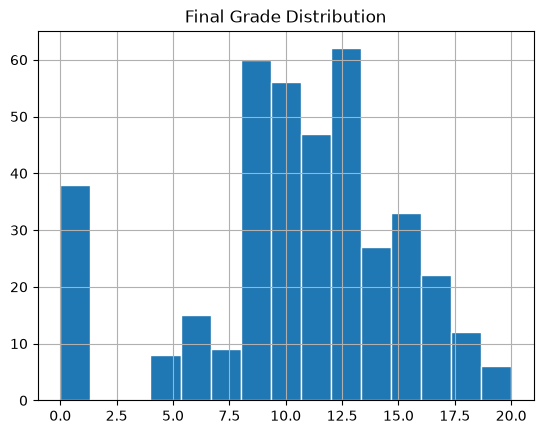

In [29]:
df['G3'].hist(bins=15, edgecolor = 'white')
plt.title('Final Grade Distribution')
plt.show()

In [30]:
df['G3'].value_counts().sort_index(ascending=True)

G3
0     38
4      1
5      7
6     15
7      9
8     32
9     28
10    56
11    47
12    31
13    31
14    27
15    33
16    16
17     6
18    12
19     5
20     1
Name: count, dtype: int64

<Axes: >

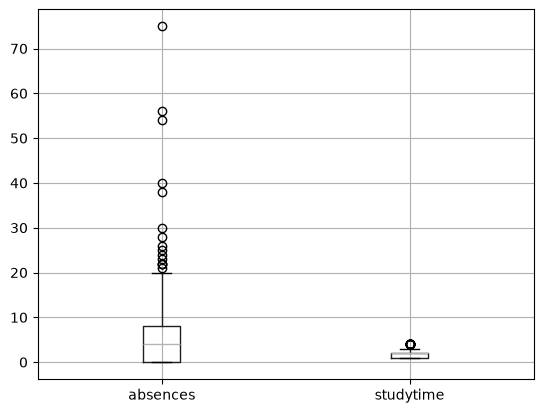

In [31]:
df.boxplot(column=['absences', 'studytime'])

1         Axes(0.1,0.559091;0.363636x0.340909)
2    Axes(0.536364,0.559091;0.363636x0.340909)
3             Axes(0.1,0.15;0.363636x0.340909)
4        Axes(0.536364,0.15;0.363636x0.340909)
dtype: object

<Figure size 1000x1000 with 0 Axes>

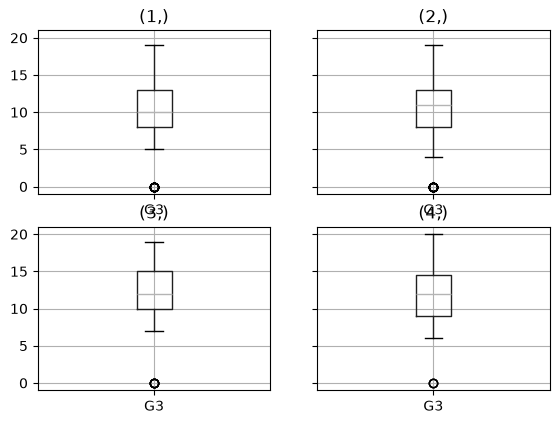

In [32]:
plt.figure(figsize=(10, 10))
df.groupby(by=['studytime']).boxplot(column='G3')

In [33]:
df_studytimegrouped = df.groupby('studytime')
df_studytimegrouped.size()

studytime
1    105
2    198
3     65
4     27
dtype: int64

0         Axes(0.1,0.559091;0.363636x0.340909)
1    Axes(0.536364,0.559091;0.363636x0.340909)
2             Axes(0.1,0.15;0.363636x0.340909)
3        Axes(0.536364,0.15;0.363636x0.340909)
dtype: object

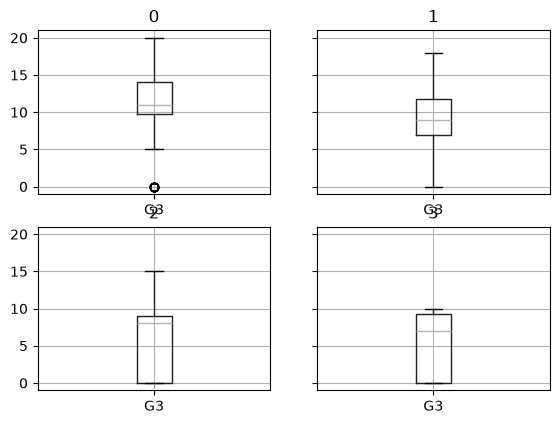

In [36]:
df_failuresgrouped = df.groupby('failures')
df_failuresgrouped.boxplot(column='G3')

In [37]:
df_failuresgrouped.size()

failures
0    312
1     50
2     17
3     16
dtype: int64

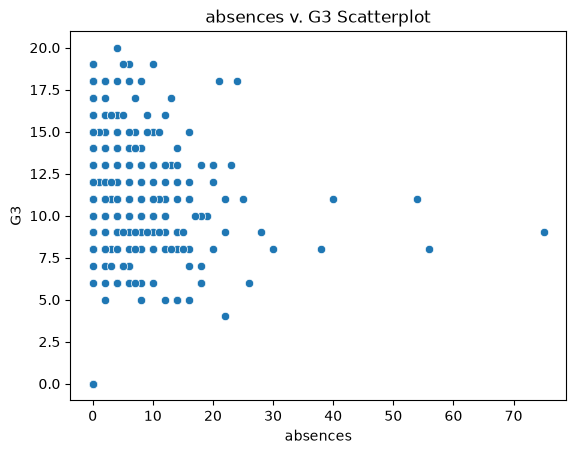

In [38]:
df_abs_gt3 = df[['absences', 'G3']]
sns.scatterplot(data=df_abs_gt3, x='absences', y='G3')
plt.title('absences v. G3 Scatterplot')
plt.show()

In [39]:
df[['failures', 'G3']].corr(method='spearman')

,failures,G3
failures,1.000000,-0.361224
G3,-0.361224,1.000000


In [40]:
df[['studytime', 'G3']].corr(method='spearman')

,studytime,G3
studytime,1.00000,0.10517
G3,0.10517,1.00000


In [41]:
df[['absences', 'G3']].corr(method='spearman')

,absences,G3
absences,1.000000,0.017731
G3,0.017731,1.000000


GP         Axes(0.1,0.15;0.363636x0.75)
MS    Axes(0.536364,0.15;0.363636x0.75)
dtype: object

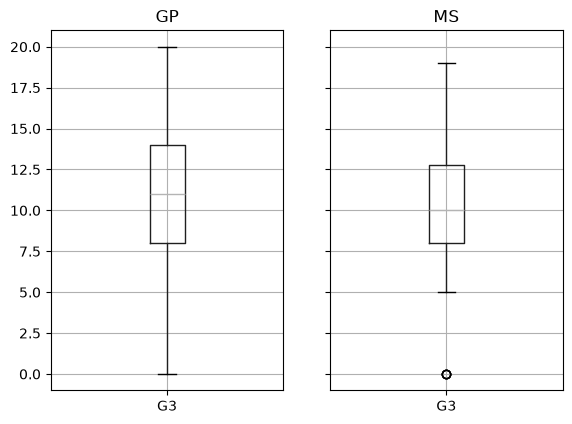

In [42]:
df_schoolgrouped = df.groupby('school')
df_schoolgrouped.boxplot(column='G3')

F         Axes(0.1,0.15;0.363636x0.75)
M    Axes(0.536364,0.15;0.363636x0.75)
dtype: object

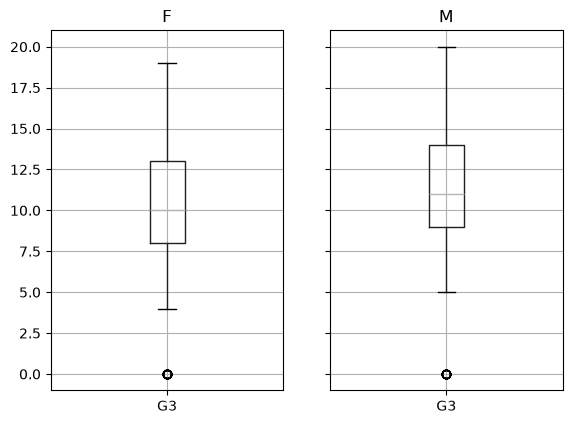

In [43]:
df_gendergrouped = df.groupby('sex')
df_gendergrouped.boxplot(column='G3')

R         Axes(0.1,0.15;0.363636x0.75)
U    Axes(0.536364,0.15;0.363636x0.75)
dtype: object

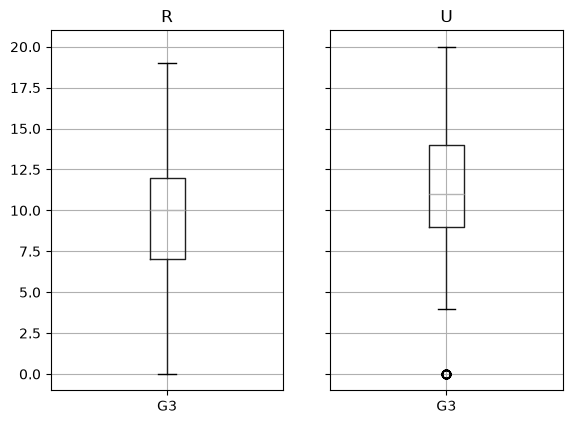

In [44]:
df_addressgrouped = df.groupby('address')
df_addressgrouped.boxplot(column='G3')

no          Axes(0.1,0.15;0.363636x0.75)
yes    Axes(0.536364,0.15;0.363636x0.75)
dtype: object

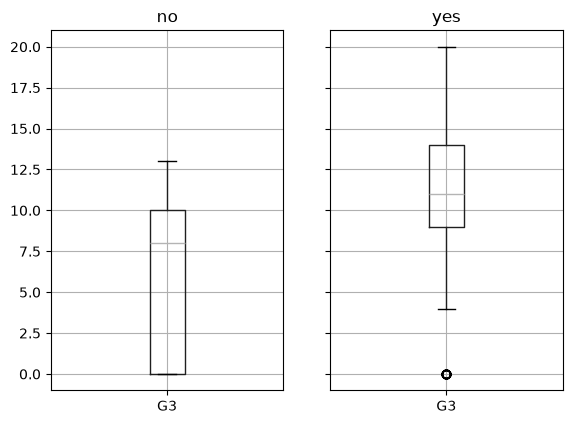

In [45]:
df_highergrouped = df.groupby('higher')
df_highergrouped.boxplot(column='G3')

<Axes: >

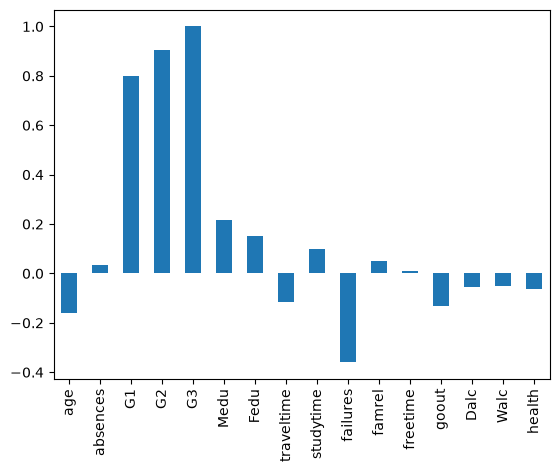

In [46]:
df[numerical_cols + ordinal_cols].corr(numeric_only=True)['G3'].plot(kind='bar')

<Axes: >

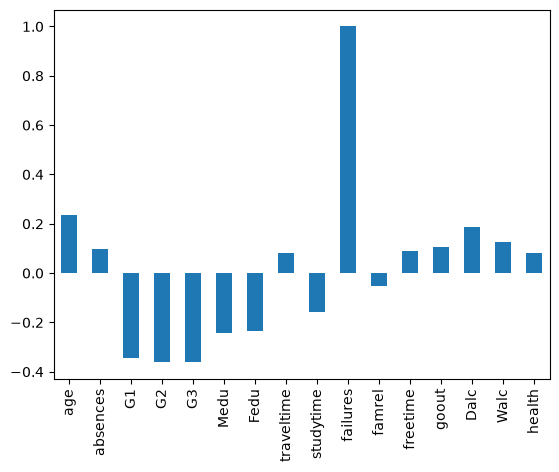

In [47]:
df[numerical_cols + ordinal_cols].corr(method='spearman',numeric_only=True)['failures'].plot(kind='bar')

In [48]:
df[['age', 'Medu', 'Fedu', 'studytime', 'failures', 'G3']].corr(method='spearman')

,age,Medu,Fedu,studytime,failures,G3
age,1.000000,-0.161294,-0.149596,0.031557,0.236464,-0.173438
Medu,-0.161294,1.000000,0.631577,0.063498,-0.242373,0.225036
Fedu,-0.149596,0.631577,1.000000,0.018429,-0.236616,0.170049
studytime,0.031557,0.063498,0.018429,1.000000,-0.157633,0.105170
failures,0.236464,-0.242373,-0.236616,-0.157633,1.000000,-0.361224
G3,-0.173438,0.225036,0.170049,0.105170,-0.361224,1.000000


In [49]:
df_highersummary = df_highergrouped.agg(
    NumberOfStudents = ('school', 'count'),
    MeanG3 = ('G3', 'mean'),
    MedianG3 = ('G3', 'median'),
    MinG3 = ('G3', 'min'),
    MaxG3 = ('G3', 'max')
)

df_highersummary

,NumberOfStudents,MeanG3,MedianG3,MinG3,MaxG3
higher,,,,,
no,20,6.800,8.0,0,13
yes,375,10.608,11.0,0,20


In [50]:
df_internetgrouped = df.groupby('internet')

df_internetgrouped.agg(
    NumberOfStudents = ('school', 'count'),
    MeanG3 = ('G3', 'mean'),
    MedianG3 = ('G3', 'median'),
    MinG3 = ('G3', 'min'),
    MaxG3 = ('G3', 'max')
)

,NumberOfStudents,MeanG3,MedianG3,MinG3,MaxG3
internet,,,,,
no,66,9.409091,10.0,0,18
yes,329,10.617021,11.0,0,20


In [51]:
df_schoolsupgrouped = df.groupby('schoolsup')

df_schoolsupgrouped.agg(
    NumberOfStudents = ('school', 'count'),
    MeanG3 = ('G3', 'mean'),
    MedianG3 = ('G3', 'median'),
    MinG3 = ('G3', 'min'),
    MaxG3 = ('G3', 'max')
)


,NumberOfStudents,MeanG3,MedianG3,MinG3,MaxG3
schoolsup,,,,,
no,344,10.561047,11.0,0,20
yes,51,9.431373,10.0,0,17


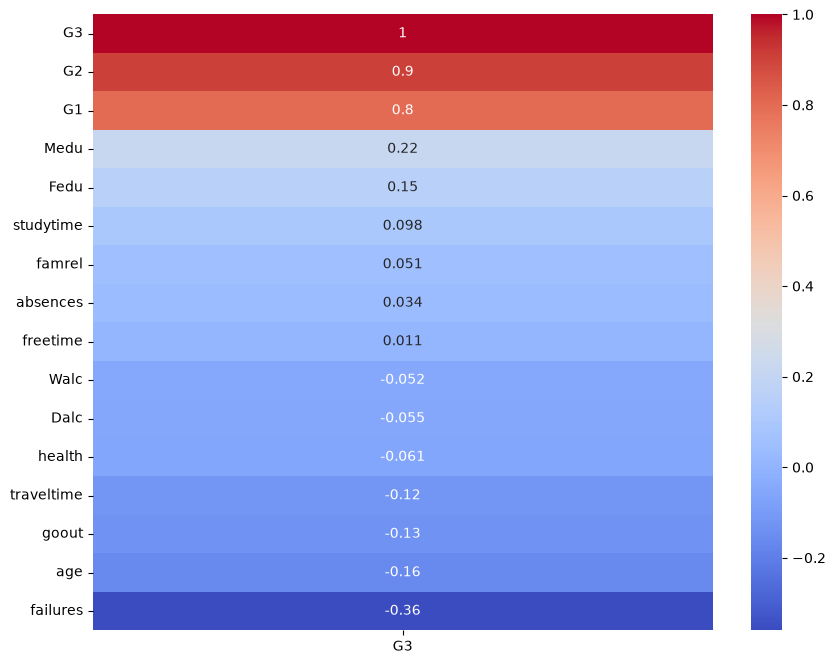

In [52]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True)[['G3']].sort_values('G3', ascending=False), annot=True, cmap='coolwarm')
plt.show()


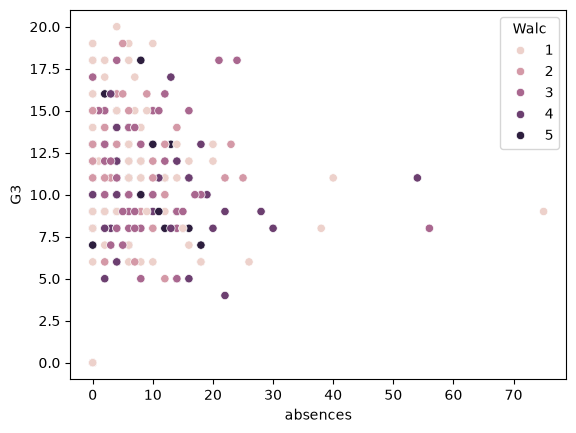

In [53]:
sns.scatterplot(data=df, x='absences', y='G3', hue='Walc')
plt.show()

In [54]:
df.select_dtypes(include='str').columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')

--- sex vs G3 ---
sex
F    10.0
M    11.0
Name: G3, dtype: float64


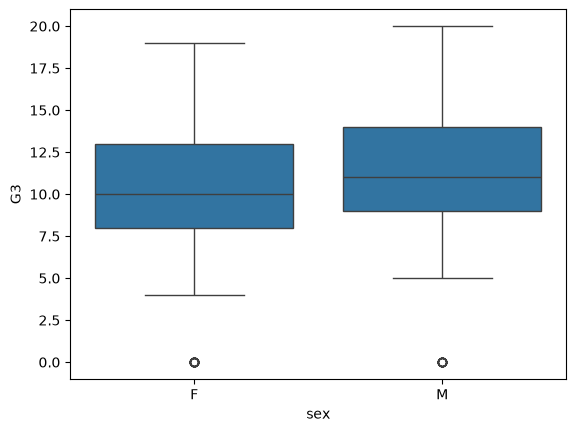

--- internet vs G3 ---
internet
no     10.0
yes    11.0
Name: G3, dtype: float64


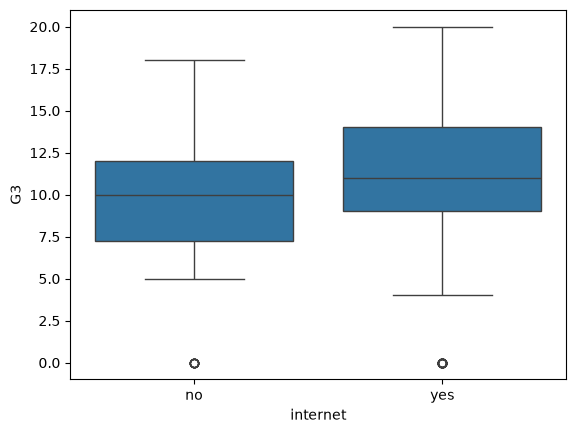

--- higher vs G3 ---
higher
no      8.0
yes    11.0
Name: G3, dtype: float64


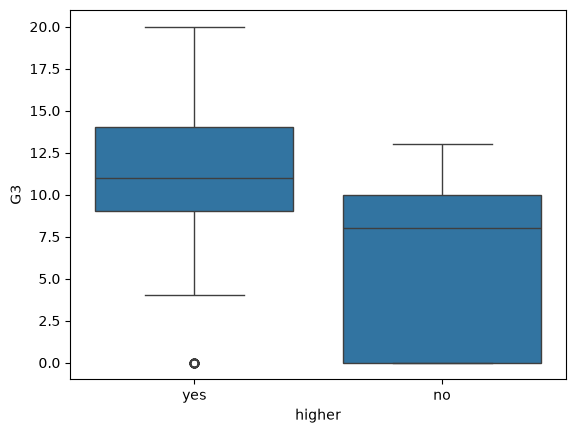

--- schoolsup vs G3 ---
schoolsup
no     11.0
yes    10.0
Name: G3, dtype: float64


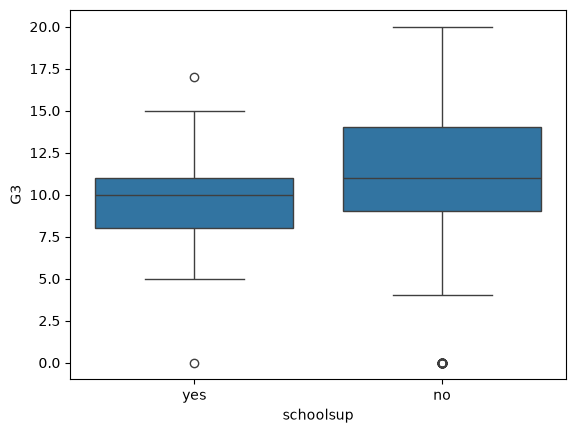

In [55]:
for col in ['sex', 'internet', 'higher', 'schoolsup'][:4]:
    print(f'--- {col} vs G3 ---')
    print(df.groupby(col)['G3'].median())
    sns.boxplot(df, x=col, y='G3')
    plt.show()

In [56]:
x_numerical = df.select_dtypes('number').drop(columns=['G1', 'G2', 'G3'])
MI_num = mutual_info_regression(x_numerical, df['G3'])
MI_df = pd.DataFrame({'feature' : x_numerical.columns, 'MI_Score' : MI_num}).sort_values(by='MI_Score', ascending=False)
print('\nTop 10 features by mutual info: ')
print(MI_df.head(10))


Top 10 features by mutual info: 
       feature  MI_Score
12    absences  0.142084
4    studytime  0.077793
9         Dalc  0.070712
5     failures  0.068360
2         Fedu  0.037353
10        Walc  0.029015
1         Medu  0.024832
3   traveltime  0.000000
0          age  0.000000
8        goout  0.000000


      feature  importance
12   absences    0.217505
5    failures    0.146849
11     health    0.075080
8       goout    0.074875
0         age    0.070938
7    freetime    0.069218
1        Medu    0.057143
10       Walc    0.055516
4   studytime    0.055094
6      famrel    0.053678


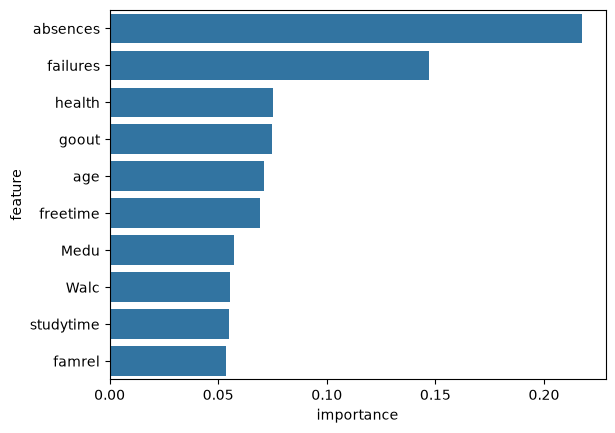

In [57]:
RGR = RandomForestRegressor(random_state=0)
RGR.fit(x_numerical, df['G3'])
importance = pd.DataFrame({'feature' : x_numerical.columns, 'importance' : RGR.feature_importances_}).sort_values('importance', ascending=False)
print(importance.head(10))
sns.barplot(data=importance.head(10), x='importance', y='feature')
plt.show()

<Axes: xlabel='higher', ylabel='G3'>

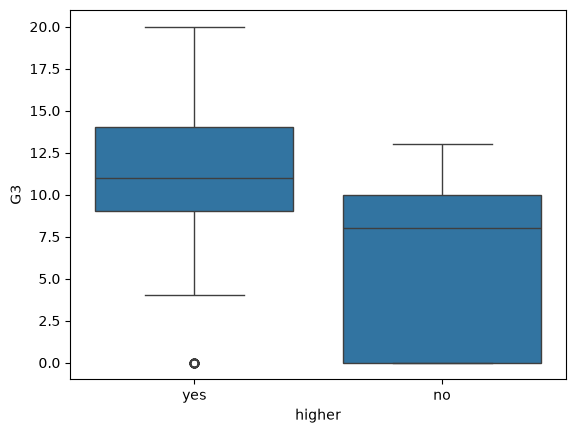

In [63]:
sns.boxplot(df, x='higher', y='G3')